# TP3 - Deep Learning: MLP do zero no Adult Income

Este notebook implementa uma rede neural artificial **do zero** para o tema **Adult Income (UCI)**, seguindo o enunciado do TP3 e o guia exploratório do projeto.

Objetivos cobertos:

- Forward pass, backpropagation e atualização por mini-batch gradient descent.
- ReLU nas camadas escondidas, Softmax na saída e Cross-Entropy como função de custo.
- Curvas de loss e acurácia em treino/teste.
- Experimentos com taxa de aprendizado, tamanho do batch e arquitetura.
- Análise de viés para atributos sensíveis (`sex` e `race`).
- Mitigação simples por reponderação (`reweighing`).
- Interpretabilidade por permutation importance e gradientes de entrada.

Fonte do dataset: UCI Machine Learning Repository, Adult Dataset, https://archive.ics.uci.edu/ml/datasets/Adult.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
rng = np.random.default_rng(SEED)

# Mantenha False para máxima compatibilidade na entrega. Se tiver CuPy instalado e CUDA,
# altere para True para treinar na GPU sem mudar a implementação da rede.
USE_CUPY = False

if USE_CUPY:
    try:
        import cupy as cp
        xp = cp
        BACKEND = 'cupy'
    except Exception as exc:
        print(f'CuPy indisponível ({exc}). Usando NumPy.')
        xp = np
        BACKEND = 'numpy'
else:
    xp = np
    BACKEND = 'numpy'

print(f'Backend numérico: {BACKEND}')

Backend numérico: numpy


## 1. Carregamento do dataset

O Adult Income possui a partição original de treino (`adult.data`) e teste (`adult.test`). O alvo é binário: `<=50K` ou `>50K`.

A limpeza abaixo remove espaços, normaliza o ponto final presente no arquivo de teste e preserva valores ausentes `?` como a categoria `Unknown`, em vez de descartar linhas.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
print(f'Diretório de dados: {DATA_DIR}')

ADULT_URLS = {
    'adult.data': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    'adult.test': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test',
    'adult.names': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names',
}

COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

NUMERIC_COLS = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
CATEGORICAL_COLS = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
TARGET_COL = 'income'


def download_adult_files():
    for filename, url in ADULT_URLS.items():
        dest = DATA_DIR / filename
        if not dest.exists():
            print(f'Baixando {filename}...')
            urlretrieve(url, dest)


def read_adult_file(path, is_test=False):
    df = pd.read_csv(
        path,
        names=COLUMNS,
        sep=',',
        skipinitialspace=True,
        skiprows=1 if is_test else 0,
        na_values=[],
        keep_default_na=False,
    )
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    df[TARGET_COL] = df[TARGET_COL].str.replace('.', '', regex=False)
    return df


def clean_adult(df):
    cleaned = df.copy()
    for col in CATEGORICAL_COLS:
        cleaned[col] = cleaned[col].replace('?', 'Unknown')
    for col in NUMERIC_COLS:
        cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')
    return cleaned


download_adult_files()
train_raw = read_adult_file(DATA_DIR / 'adult.data')
test_raw = read_adult_file(DATA_DIR / 'adult.test', is_test=True)

train_df = clean_adult(train_raw)
test_df = clean_adult(test_raw)

print('Treino:', train_df.shape)
print('Teste :', test_df.shape)
train_df.head()

Diretório de dados: /home/jmvjr/Documentos/unicamp/Mc906/Deep-Learning-Adult-Income/data
Treino: (32561, 15)
Teste : (16281, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. EDA rápida

Aqui observamos distribuição de classes, valores ausentes mascarados e disparidades iniciais por grupos sensíveis. Essa parte sustenta a discussão crítica do relatório.

Distribuição do alvo no treino


,n,%
income,,
<=50K,24720,75.92
>50K,7841,24.08


Valores Unknown por coluna categórica


,unknown_count
occupation,1843
workclass,1836
native_country,583
marital_status,0
relationship,0
race,0
sex,0


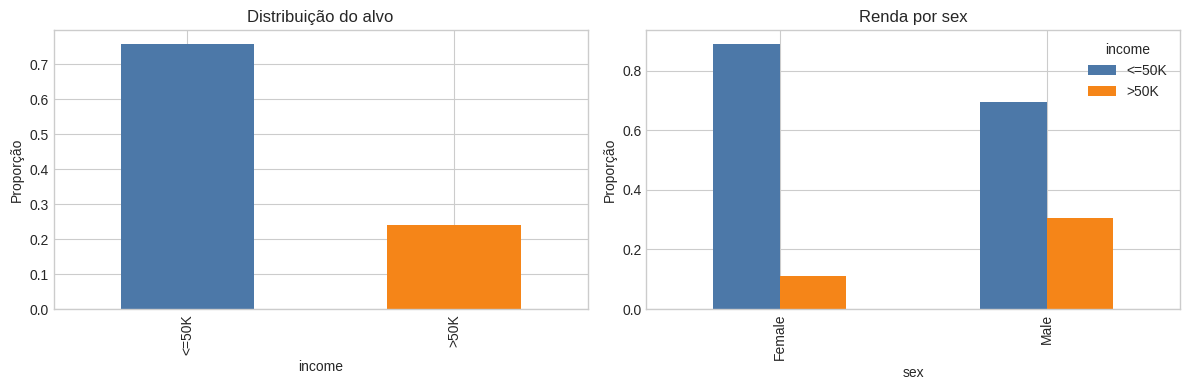

In [3]:
def class_table(df, col=TARGET_COL):
    counts = df[col].value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({'n': counts, '%': pct})

print('Distribuição do alvo no treino')
display(class_table(train_df))

print('Valores Unknown por coluna categórica')
unknown_counts = (train_df[CATEGORICAL_COLS] == 'Unknown').sum().sort_values(ascending=False)
display(unknown_counts.to_frame('unknown_count'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df[TARGET_COL].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('Distribuição do alvo')
axes[0].set_ylabel('Proporção')

pd.crosstab(train_df['sex'], train_df[TARGET_COL], normalize='index').sort_index().plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518'])
axes[1].set_title('Renda por sex')
axes[1].set_ylabel('Proporção')
axes[1].legend(title='income')
plt.tight_layout()
plt.show()

In [4]:
print('Taxa real de >50K por sex')
display(pd.crosstab(train_df['sex'], train_df[TARGET_COL], normalize='index')['>50K'].sort_values(ascending=False).to_frame('P(>50K)'))

print('Taxa real de >50K por race')
display(pd.crosstab(train_df['race'], train_df[TARGET_COL], normalize='index')['>50K'].sort_values(ascending=False).to_frame('P(>50K)'))

Taxa real de >50K por sex


,P(>50K)
sex,
Male,0.305737
Female,0.109461


Taxa real de >50K por race


,P(>50K)
race,
Asian-Pac-Islander,0.265640
White,0.255860
Black,0.123880
Amer-Indian-Eskimo,0.115756
Other,0.092251


## 3. Pré-processamento

Decisões principais:

- `education` é removida porque é redundante com `education_num`.
- Variáveis numéricas são padronizadas com Z-score usando estatísticas do treino.
- Variáveis categóricas recebem one-hot encoding ajustado no treino e aplicado ao teste.
- O alvo é codificado como `0 = <=50K` e `1 = >50K`.

In [5]:
class AdultPreprocessor:
    def __init__(self, numeric_cols, categorical_cols, drop_cols=None):
        self.numeric_cols = list(numeric_cols)
        self.categorical_cols = list(categorical_cols)
        self.drop_cols = set(drop_cols or [])
        self.numeric_cols = [c for c in self.numeric_cols if c not in self.drop_cols]
        self.categorical_cols = [c for c in self.categorical_cols if c not in self.drop_cols]
        self.means_ = None
        self.stds_ = None
        self.categories_ = {}
        self.feature_names_ = []
        self.feature_groups_ = {}

    def fit(self, df):
        self.means_ = df[self.numeric_cols].mean()
        self.stds_ = df[self.numeric_cols].std(ddof=0).replace(0, 1)
        for col in self.categorical_cols:
            cats = sorted(df[col].astype(str).unique().tolist())
            if 'Unknown' not in cats:
                cats.append('Unknown')
            self.categories_[col] = cats
        self._build_feature_metadata()
        return self

    def _build_feature_metadata(self):
        names = []
        groups = {}
        idx = 0
        for col in self.numeric_cols:
            names.append(col)
            groups[col] = [idx]
            idx += 1
        for col in self.categorical_cols:
            indices = []
            for cat in self.categories_[col]:
                names.append(f'{col}={cat}')
                indices.append(idx)
                idx += 1
            groups[col] = indices
        self.feature_names_ = names
        self.feature_groups_ = groups

    def transform(self, df):
        parts = []
        if self.numeric_cols:
            X_num = ((df[self.numeric_cols] - self.means_) / self.stds_).to_numpy(dtype=np.float32)
            parts.append(X_num)
        for col in self.categorical_cols:
            cats = self.categories_[col]
            values = df[col].astype(str).where(df[col].astype(str).isin(cats), 'Unknown')
            codes = pd.Categorical(values, categories=cats).codes
            one_hot = np.zeros((len(df), len(cats)), dtype=np.float32)
            valid = codes >= 0
            one_hot[np.arange(len(df))[valid], codes[valid]] = 1.0
            parts.append(one_hot)
        return np.concatenate(parts, axis=1).astype(np.float32)

    def fit_transform(self, df):
        return self.fit(df).transform(df)


def encode_target(series):
    return (series.astype(str).str.strip() == '>50K').to_numpy(dtype=np.int64)

preprocessor = AdultPreprocessor(
    numeric_cols=NUMERIC_COLS,
    categorical_cols=CATEGORICAL_COLS,
    drop_cols=['education'],
)

X_train = preprocessor.fit_transform(train_df)
X_test = preprocessor.transform(test_df)
y_train = encode_target(train_df[TARGET_COL])
y_test = encode_target(test_df[TARGET_COL])

sensitive_train = {
    'sex': train_df['sex'].to_numpy(),
    'race': train_df['race'].to_numpy(),
}
sensitive_test = {
    'sex': test_df['sex'].to_numpy(),
    'race': test_df['race'].to_numpy(),
}

print('Dimensão X_train:', X_train.shape)
print('Dimensão X_test :', X_test.shape)
print('Primeiras features:', preprocessor.feature_names_[:12])

Dimensão X_train: (32561, 96)
Dimensão X_test : (16281, 96)
Primeiras features: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass=Federal-gov', 'workclass=Local-gov', 'workclass=Never-worked', 'workclass=Private', 'workclass=Self-emp-inc', 'workclass=Self-emp-not-inc']


## 4. Métricas de desempenho e fairness

A acurácia sozinha é insuficiente porque a classe `<=50K` domina a base. Por isso o notebook também calcula precision, recall e F1 para a classe positiva `>50K`.

Para viés, usamos:

- **Statistical Parity Difference (SPD)**: diferença entre taxas de seleção do grupo não privilegiado e privilegiado.
- **Disparate Impact (DI)**: razão entre essas taxas. Valores próximos de `1` indicam paridade; a regra prática dos quatro quintos considera `DI < 0.8` como alerta.

In [6]:
def to_numpy(a):
    if BACKEND == 'cupy':
        return xp.asnumpy(a)
    return np.asarray(a)


def one_hot(y, num_classes=2, backend=np):
    y = backend.asarray(y, dtype=backend.int64)
    out = backend.zeros((y.shape[0], num_classes), dtype=backend.float32)
    out[backend.arange(y.shape[0]), y] = 1.0
    return out


def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    acc = (tp + tn) / max(len(y_true), 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


def fairness_metrics(y_pred, sensitive, unprivileged, privileged):
    y_pred = np.asarray(y_pred).astype(int)
    sensitive = np.asarray(sensitive).astype(str)
    mask_unpriv = sensitive == unprivileged
    mask_priv = sensitive == privileged
    rate_unpriv = y_pred[mask_unpriv].mean() if mask_unpriv.any() else np.nan
    rate_priv = y_pred[mask_priv].mean() if mask_priv.any() else np.nan
    spd = rate_unpriv - rate_priv
    di = rate_unpriv / rate_priv if rate_priv not in [0, np.nan] and rate_priv > 0 else np.nan
    return {
        'unprivileged': unprivileged,
        'privileged': privileged,
        'selection_rate_unprivileged': rate_unpriv,
        'selection_rate_privileged': rate_priv,
        'statistical_parity_difference': spd,
        'disparate_impact': di,
    }


def metrics_frame(metrics_dict):
    keys = ['accuracy', 'precision', 'recall', 'f1', 'tp', 'tn', 'fp', 'fn']
    return pd.DataFrame({k: [metrics_dict[k]] for k in keys})

## 5. MLP implementada do zero

A classe abaixo implementa manualmente:

- Inicialização He nas camadas com ReLU.
- Inicialização Xavier na camada de saída.
- Forward pass com ReLU e Softmax estável.
- Cross-entropy com opção de pesos por amostra.
- Backpropagation vetorizado.
- Mini-batch gradient descent com L2 e momentum opcional.

In [7]:
class MLPFromScratch:
    def __init__(self, layer_sizes, seed=42, l2=0.0, momentum=0.0, backend=np):
        self.layer_sizes = list(layer_sizes)
        self.l2 = float(l2)
        self.momentum = float(momentum)
        self.xp = backend
        self.rng = np.random.default_rng(seed)
        self.params = []
        self.velocities = []
        self._init_params()

    def _as_backend(self, arr, dtype=None):
        if dtype is None:
            return self.xp.asarray(arr)
        return self.xp.asarray(arr, dtype=dtype)

    def _init_params(self):
        self.params = []
        self.velocities = []
        n_layers = len(self.layer_sizes) - 1
        for i in range(n_layers):
            fan_in = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]
            if i < n_layers - 1:
                W_np = self.rng.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out)).astype(np.float32)
            else:
                limit = np.sqrt(6.0 / (fan_in + fan_out))
                W_np = self.rng.uniform(-limit, limit, size=(fan_in, fan_out)).astype(np.float32)
            b_np = np.zeros((1, fan_out), dtype=np.float32)
            W = self._as_backend(W_np, dtype=self.xp.float32)
            b = self._as_backend(b_np, dtype=self.xp.float32)
            self.params.append({'W': W, 'b': b})
            self.velocities.append({
                'W': self.xp.zeros_like(W),
                'b': self.xp.zeros_like(b),
            })

    def relu(self, Z):
        return self.xp.maximum(Z, 0)

    def relu_grad(self, Z):
        return (Z > 0).astype(self.xp.float32)

    def softmax(self, Z):
        shifted = Z - self.xp.max(Z, axis=1, keepdims=True)
        exp_scores = self.xp.exp(shifted)
        return exp_scores / self.xp.sum(exp_scores, axis=1, keepdims=True)

    def forward(self, X, return_cache=True):
        A = X
        cache = {'A': [A], 'Z': []}
        for i, layer in enumerate(self.params):
            Z = A @ layer['W'] + layer['b']
            cache['Z'].append(Z)
            if i < len(self.params) - 1:
                A = self.relu(Z)
            else:
                A = self.softmax(Z)
            cache['A'].append(A)
        if return_cache:
            return A, cache
        return A

    def compute_loss(self, probs, y, sample_weight=None):
        y_oh = one_hot(y, probs.shape[1], backend=self.xp)
        eps = self.xp.asarray(1e-12, dtype=self.xp.float32)
        per_sample = -self.xp.sum(y_oh * self.xp.log(self.xp.clip(probs, eps, 1.0)), axis=1)
        if sample_weight is None:
            data_loss = self.xp.mean(per_sample)
        else:
            weights = sample_weight.astype(self.xp.float32)
            data_loss = self.xp.sum(weights * per_sample) / self.xp.sum(weights)
        l2_loss = 0.0
        if self.l2 > 0:
            for layer in self.params:
                l2_loss += self.xp.sum(layer['W'] ** 2)
            l2_loss = 0.5 * self.l2 * l2_loss
        return data_loss + l2_loss

    def backward(self, cache, y, sample_weight=None):
        y_oh = one_hot(y, self.layer_sizes[-1], backend=self.xp)
        probs = cache['A'][-1]
        m = y_oh.shape[0]

        dZ = probs - y_oh
        if sample_weight is None:
            dZ = dZ / m
        else:
            weights = sample_weight.astype(self.xp.float32).reshape(-1, 1)
            dZ = dZ * weights / self.xp.sum(weights)

        grads = [None] * len(self.params)
        for i in reversed(range(len(self.params))):
            A_prev = cache['A'][i]
            dW = A_prev.T @ dZ
            db = self.xp.sum(dZ, axis=0, keepdims=True)
            if self.l2 > 0:
                dW = dW + self.l2 * self.params[i]['W']
            grads[i] = {'W': dW, 'b': db}
            if i > 0:
                dA_prev = dZ @ self.params[i]['W'].T
                dZ = dA_prev * self.relu_grad(cache['Z'][i - 1])
        return grads

    def step(self, grads, lr):
        for i, grad in enumerate(grads):
            if self.momentum > 0:
                self.velocities[i]['W'] = self.momentum * self.velocities[i]['W'] - lr * grad['W']
                self.velocities[i]['b'] = self.momentum * self.velocities[i]['b'] - lr * grad['b']
                self.params[i]['W'] = self.params[i]['W'] + self.velocities[i]['W']
                self.params[i]['b'] = self.params[i]['b'] + self.velocities[i]['b']
            else:
                self.params[i]['W'] = self.params[i]['W'] - lr * grad['W']
                self.params[i]['b'] = self.params[i]['b'] - lr * grad['b']

    def predict_proba(self, X):
        Xb = self._as_backend(X, dtype=self.xp.float32)
        probs = self.forward(Xb, return_cache=False)
        return to_numpy(probs)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def input_gradients(self, X, class_idx=None):
        Xb = self._as_backend(X, dtype=self.xp.float32)
        probs, cache = self.forward(Xb, return_cache=True)
        if class_idx is None:
            class_idx = self.xp.argmax(probs, axis=1)
        class_idx = self.xp.asarray(class_idx, dtype=self.xp.int64)
        dZ = self.xp.zeros_like(cache['Z'][-1])
        dZ[self.xp.arange(Xb.shape[0]), class_idx] = 1.0
        for i in reversed(range(len(self.params))):
            if i == 0:
                dX = dZ @ self.params[i]['W'].T
            else:
                dA_prev = dZ @ self.params[i]['W'].T
                dZ = dA_prev * self.relu_grad(cache['Z'][i - 1])
        return to_numpy(dX)

In [8]:
def evaluate_model(model, X, y):
    pred = model.predict(X)
    return classification_metrics(y, pred)


def train_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=30,
    batch_size=256,
    lr=0.05,
    lr_decay=0.0,
    sample_weight=None,
    seed=42,
    verbose=True,
):
    local_rng = np.random.default_rng(seed)
    n = X_train.shape[0]
    X_train_b = model._as_backend(X_train, dtype=model.xp.float32)
    y_train_b = model._as_backend(y_train, dtype=model.xp.int64)
    weights_b = None if sample_weight is None else model._as_backend(sample_weight, dtype=model.xp.float32)
    history = []

    for epoch in range(1, epochs + 1):
        indices = local_rng.permutation(n)
        current_lr = lr / (1.0 + lr_decay * (epoch - 1))
        batch_losses = []

        for start in range(0, n, batch_size):
            batch_idx_np = indices[start:start + batch_size]
            batch_idx = model._as_backend(batch_idx_np, dtype=model.xp.int64)
            Xb = X_train_b[batch_idx]
            yb = y_train_b[batch_idx]
            wb = None if weights_b is None else weights_b[batch_idx]

            probs, cache = model.forward(Xb, return_cache=True)
            loss = model.compute_loss(probs, yb, sample_weight=wb)
            grads = model.backward(cache, yb, sample_weight=wb)
            model.step(grads, current_lr)
            batch_losses.append(float(to_numpy(loss)))

        train_metrics = evaluate_model(model, X_train, y_train)
        test_metrics = evaluate_model(model, X_test, y_test)
        row = {
            'epoch': epoch,
            'lr': current_lr,
            'loss': float(np.mean(batch_losses)),
            'train_accuracy': train_metrics['accuracy'],
            'test_accuracy': test_metrics['accuracy'],
            'train_f1': train_metrics['f1'],
            'test_f1': test_metrics['f1'],
        }
        history.append(row)
        if verbose and (epoch == 1 or epoch % max(1, epochs // 5) == 0 or epoch == epochs):
            print(
                f"epoch {epoch:03d}/{epochs} | loss={row['loss']:.4f} | "
                f"acc_train={row['train_accuracy']:.4f} | acc_test={row['test_accuracy']:.4f} | "
                f"f1_test={row['test_f1']:.4f}"
            )

    return pd.DataFrame(history)


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['epoch'], history['loss'], color='#4C78A8')
    axes[0].set_title(f'{title} - Loss de treino')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-entropy')

    axes[1].plot(history['epoch'], history['train_accuracy'], label='Treino', color='#4C78A8')
    axes[1].plot(history['epoch'], history['test_accuracy'], label='Teste', color='#F58518')
    axes[1].set_title(f'{title} - Acurácia')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 6. Modelo base

A arquitetura base usa duas camadas escondidas. Ela é propositalmente simples, mas já contém bons extras do guia: inicialização He/Xavier, L2 e momentum.

epoch 001/25 | loss=0.3579 | acc_train=0.8526 | acc_test=0.8549 | f1_test=0.6494
epoch 005/25 | loss=0.3142 | acc_train=0.8591 | acc_test=0.8589 | f1_test=0.6683
epoch 010/25 | loss=0.3093 | acc_train=0.8623 | acc_test=0.8585 | f1_test=0.6873
epoch 015/25 | loss=0.3031 | acc_train=0.8649 | acc_test=0.8552 | f1_test=0.6762
epoch 020/25 | loss=0.3006 | acc_train=0.8640 | acc_test=0.8562 | f1_test=0.6424
epoch 025/25 | loss=0.2960 | acc_train=0.8665 | acc_test=0.8530 | f1_test=0.6810


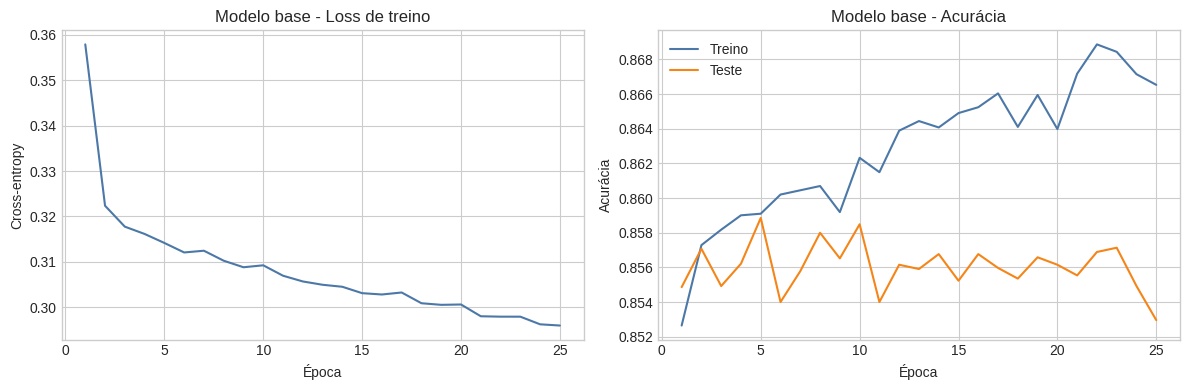

,accuracy,precision,recall,f1,tp,tn,fp,fn
0,0.852957,0.698469,0.664327,0.68097,2555,11332,1103,1291


In [9]:
input_dim = X_train.shape[1]
base_architecture = [input_dim, 64, 32, 2]

base_model = MLPFromScratch(
    base_architecture,
    seed=SEED,
    l2=1e-4,
    momentum=0.9,
    backend=xp,
)

base_history = train_model(
    base_model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=25,
    batch_size=256,
    lr=0.05,
    lr_decay=0.02,
    seed=SEED,
)

plot_history(base_history, 'Modelo base')
base_pred = base_model.predict(X_test)
base_proba = base_model.predict_proba(X_test)
base_metrics = classification_metrics(y_test, base_pred)
metrics_frame(base_metrics)

## 7. Experimentos obrigatórios

O enunciado pede avaliar o impacto de:

- Taxa de aprendizado.
- Tamanho do batch.
- Arquitetura da rede.

Para manter o notebook executável em tempo razoável, cada configuração roda por menos épocas que o modelo final.

In [10]:
def run_short_experiment(name, hidden_layers, lr, batch_size, epochs=12, l2=1e-4, momentum=0.9):
    model = MLPFromScratch(
        [input_dim, *hidden_layers, 2],
        seed=SEED,
        l2=l2,
        momentum=momentum,
        backend=xp,
    )
    history = train_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        lr_decay=0.02,
        seed=SEED,
        verbose=False,
    )
    pred = model.predict(X_test)
    metrics = classification_metrics(y_test, pred)
    return {
        'name': name,
        'hidden_layers': str(hidden_layers),
        'lr': lr,
        'batch_size': batch_size,
        'epochs': epochs,
        **{k: metrics[k] for k in ['accuracy', 'precision', 'recall', 'f1']},
    }, history

experiments = []
histories = {}

for lr_value in [0.01, 0.05, 0.10]:
    row, hist = run_short_experiment(f'lr={lr_value}', [64, 32], lr_value, 256)
    experiments.append(row)
    histories[row['name']] = hist

for batch_value in [64, 256, 1024]:
    row, hist = run_short_experiment(f'batch={batch_value}', [64, 32], 0.05, batch_value)
    experiments.append(row)
    histories[row['name']] = hist

for arch in [[32], [64, 32], [128, 64]]:
    row, hist = run_short_experiment(f'arch={arch}', arch, 0.05, 256)
    experiments.append(row)
    histories[row['name']] = hist

experiments_df = pd.DataFrame(experiments).sort_values('f1', ascending=False)
experiments_df

,name,hidden_layers,lr,batch_size,epochs,accuracy,precision,recall,f1
2,lr=0.1,"[64, 32]",0.10,256,12,0.855230,0.700296,0.676807,0.688351
6,arch=[32],[32],0.05,256,12,0.858485,0.727434,0.641186,0.681592
7,"arch=[64, 32]","[64, 32]",0.05,256,12,0.856151,0.714489,0.651326,0.681447
4,batch=256,"[64, 32]",0.05,256,12,0.856151,0.714489,0.651326,0.681447
1,lr=0.05,"[64, 32]",0.05,256,12,0.856151,0.714489,0.651326,0.681447
8,"arch=[128, 64]","[128, 64]",0.05,256,12,0.856213,0.715308,0.650026,0.681106
5,batch=1024,"[64, 32]",0.05,1024,12,0.857564,0.726491,0.636765,0.678675
0,lr=0.01,"[64, 32]",0.01,256,12,0.858547,0.732730,0.631565,0.678397
3,batch=64,"[64, 32]",0.05,64,12,0.857441,0.731833,0.625845,0.674702


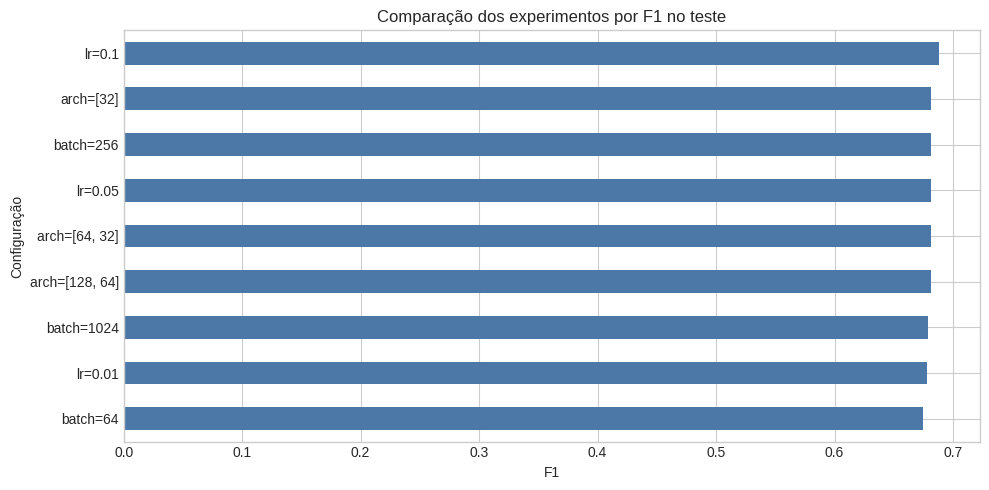

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
experiments_df.sort_values('f1').plot(kind='barh', x='name', y='f1', ax=ax, color='#4C78A8', legend=False)
ax.set_title('Comparação dos experimentos por F1 no teste')
ax.set_xlabel('F1')
ax.set_ylabel('Configuração')
plt.tight_layout()
plt.show()

## 8. Análise de viés do modelo base

Para o tema Adult Income, a parte de viés é central. Aqui medimos se a taxa de predição positiva (`>50K`) muda muito entre grupos.

In [12]:
def fairness_report(y_pred, sensitive_test):
    rows = []
    sex = fairness_metrics(y_pred, sensitive_test['sex'], unprivileged='Female', privileged='Male')
    rows.append({'attribute': 'sex', **sex})

    # Comparação racial simples: grupo Black versus White. Outras comparações podem ser adicionadas.
    race = fairness_metrics(y_pred, sensitive_test['race'], unprivileged='Black', privileged='White')
    rows.append({'attribute': 'race', **race})
    return pd.DataFrame(rows)

print('Métricas preditivas do modelo base')
display(metrics_frame(base_metrics))

print('Fairness do modelo base')
base_fairness = fairness_report(base_pred, sensitive_test)
display(base_fairness)

print('Taxa de seleção positiva por sex')
display(pd.DataFrame({'sex': sensitive_test['sex'], 'pred_>50K': base_pred}).groupby('sex')['pred_>50K'].mean().to_frame())

print('Taxa de seleção positiva por race')
display(pd.DataFrame({'race': sensitive_test['race'], 'pred_>50K': base_pred}).groupby('race')['pred_>50K'].mean().sort_values(ascending=False).to_frame())

Métricas preditivas do modelo base


,accuracy,precision,recall,f1,tp,tn,fp,fn
0,0.852957,0.698469,0.664327,0.68097,2555,11332,1103,1291


Fairness do modelo base


,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact
0,sex,Female,Male,0.093156,0.290331,-0.197175,0.320862
1,race,Black,White,0.106983,0.239710,-0.132728,0.446300


Taxa de seleção positiva por sex


,pred_>50K
sex,
Female,0.093156
Male,0.290331


Taxa de seleção positiva por race


,pred_>50K
race,
Asian-Pac-Islander,0.256250
White,0.239710
Black,0.106983
Other,0.096296
Amer-Indian-Eskimo,0.075472


## 9. Mitigação simples: Reweighing

A mitigação abaixo altera a importância das amostras durante o treino. A ideia é dar maior peso a combinações sub-representadas de grupo sensível e classe, sem alterar os rótulos e sem gerar amostras artificiais.

A fórmula usada é:

\[
w(a, y) = \frac{P(A=a)P(Y=y)}{P(A=a, Y=y)}
\]

Aqui aplicamos a reponderação usando `sex` como atributo sensível.

count    32561.000000
mean         1.000000
std          0.268028
min          0.787637
25%          0.852506
50%          1.093519
75%          1.093519
max          2.199966
dtype: float64
epoch 001/25 | loss=0.3636 | acc_train=0.8486 | acc_test=0.8458 | f1_test=0.6175
epoch 005/25 | loss=0.3185 | acc_train=0.8547 | acc_test=0.8496 | f1_test=0.6305
epoch 010/25 | loss=0.3125 | acc_train=0.8577 | acc_test=0.8522 | f1_test=0.6544
epoch 015/25 | loss=0.3063 | acc_train=0.8606 | acc_test=0.8522 | f1_test=0.6490
epoch 020/25 | loss=0.3024 | acc_train=0.8532 | acc_test=0.8442 | f1_test=0.5867
epoch 025/25 | loss=0.2978 | acc_train=0.8633 | acc_test=0.8493 | f1_test=0.6638


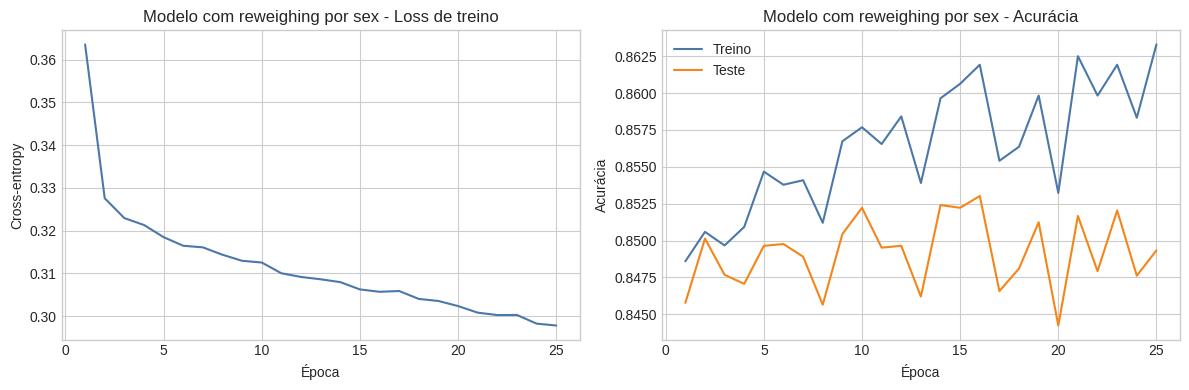

,model,accuracy,precision,recall,f1
0,base,0.852957,0.698469,0.664327,0.680970
1,reweighing_sex,0.849334,0.701826,0.629745,0.663834


,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact,model
0,sex,Female,Male,0.093156,0.290331,-0.197175,0.320862,base
1,race,Black,White,0.106983,0.239710,-0.132728,0.446300,base
2,sex,Female,Male,0.151448,0.242173,-0.090725,0.625371,reweighing_sex
3,race,Black,White,0.108264,0.224222,-0.115958,0.482843,reweighing_sex


In [13]:
def compute_reweighing_weights(y, sensitive):
    y = np.asarray(y).astype(int)
    sensitive = np.asarray(sensitive).astype(str)
    n = len(y)
    weights = np.ones(n, dtype=np.float32)
    groups = np.unique(sensitive)
    classes = np.unique(y)

    for group in groups:
        p_group = np.mean(sensitive == group)
        for cls in classes:
            p_cls = np.mean(y == cls)
            mask = (sensitive == group) & (y == cls)
            p_joint = np.mean(mask)
            if p_joint > 0:
                weights[mask] = (p_group * p_cls) / p_joint
    weights = weights / weights.mean()
    return weights.astype(np.float32)

sample_weights_sex = compute_reweighing_weights(y_train, sensitive_train['sex'])
print(pd.Series(sample_weights_sex).describe())

weighted_model = MLPFromScratch(
    base_architecture,
    seed=SEED,
    l2=1e-4,
    momentum=0.9,
    backend=xp,
)

weighted_history = train_model(
    weighted_model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=25,
    batch_size=256,
    lr=0.05,
    lr_decay=0.02,
    sample_weight=sample_weights_sex,
    seed=SEED,
)

plot_history(weighted_history, 'Modelo com reweighing por sex')
weighted_pred = weighted_model.predict(X_test)
weighted_metrics = classification_metrics(y_test, weighted_pred)
weighted_fairness = fairness_report(weighted_pred, sensitive_test)

comparison_metrics = pd.DataFrame([
    {'model': 'base', **{k: base_metrics[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
    {'model': 'reweighing_sex', **{k: weighted_metrics[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
])
comparison_fairness = pd.concat([
    base_fairness.assign(model='base'),
    weighted_fairness.assign(model='reweighing_sex'),
], ignore_index=True)

display(comparison_metrics)
display(comparison_fairness)

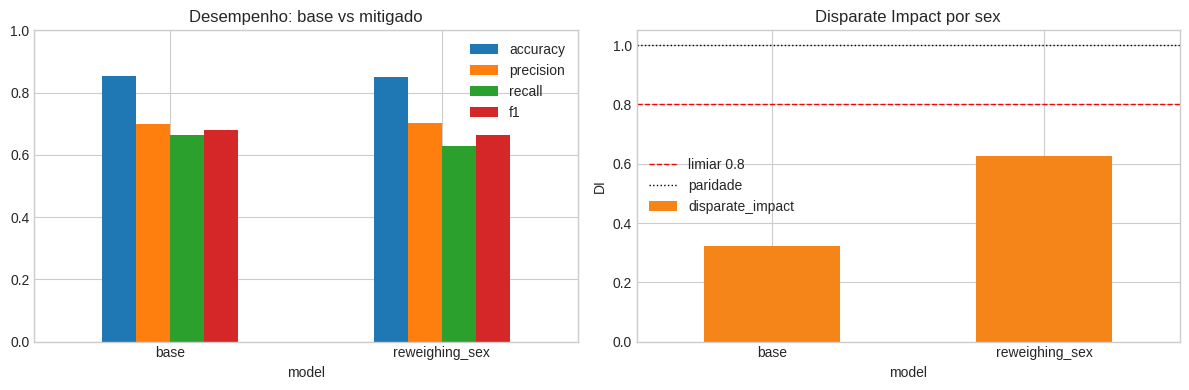

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_metrics.set_index('model')[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Desempenho: base vs mitigado')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)

sex_fair = comparison_fairness[comparison_fairness['attribute'] == 'sex'].set_index('model')
sex_fair[['disparate_impact']].plot(kind='bar', ax=axes[1], color='#F58518', legend=False)
axes[1].axhline(0.8, color='red', linestyle='--', linewidth=1, label='limiar 0.8')
axes[1].axhline(1.0, color='black', linestyle=':', linewidth=1, label='paridade')
axes[1].set_title('Disparate Impact por sex')
axes[1].set_ylabel('DI')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Interpretabilidade global: Permutation Feature Importance

A técnica embaralha uma feature original por vez e mede quanto a métrica cai. Como usamos one-hot encoding, as colunas derivadas de uma mesma variável categórica são permutadas em grupo.

In [15]:
def f1_metric(y_true, y_pred):
    return classification_metrics(y_true, y_pred)['f1']


def permutation_importance_grouped(model, X, y, feature_groups, n_repeats=3, seed=42):
    local_rng = np.random.default_rng(seed)
    base_pred = model.predict(X)
    base_score = f1_metric(y, base_pred)
    rows = []

    for group_name, cols in feature_groups.items():
        drops = []
        cols = list(cols)
        for _ in range(n_repeats):
            X_perm = X.copy()
            perm = local_rng.permutation(X.shape[0])
            X_perm[:, cols] = X_perm[perm][:, cols]
            perm_pred = model.predict(X_perm)
            perm_score = f1_metric(y, perm_pred)
            drops.append(base_score - perm_score)
        rows.append({
            'feature_group': group_name,
            'base_f1': base_score,
            'mean_drop_f1': float(np.mean(drops)),
            'std_drop_f1': float(np.std(drops)),
        })
    return pd.DataFrame(rows).sort_values('mean_drop_f1', ascending=False)

importance_df = permutation_importance_grouped(
    base_model,
    X_test,
    y_test,
    preprocessor.feature_groups_,
    n_repeats=3,
    seed=SEED,
)

importance_df.head(12)

,feature_group,base_f1,mean_drop_f1,std_drop_f1
7,marital_status,0.68097,0.113613,0.003472
2,education_num,0.68097,0.060996,0.000485
3,capital_gain,0.68097,0.060604,0.002187
0,age,0.68097,0.058499,0.003519
8,occupation,0.68097,0.037666,0.000613
5,hours_per_week,0.68097,0.027322,0.006148
9,relationship,0.68097,0.013381,0.001776
11,sex,0.68097,0.009803,0.002089
4,capital_loss,0.68097,0.006592,0.001416
6,workclass,0.68097,0.001746,0.001383


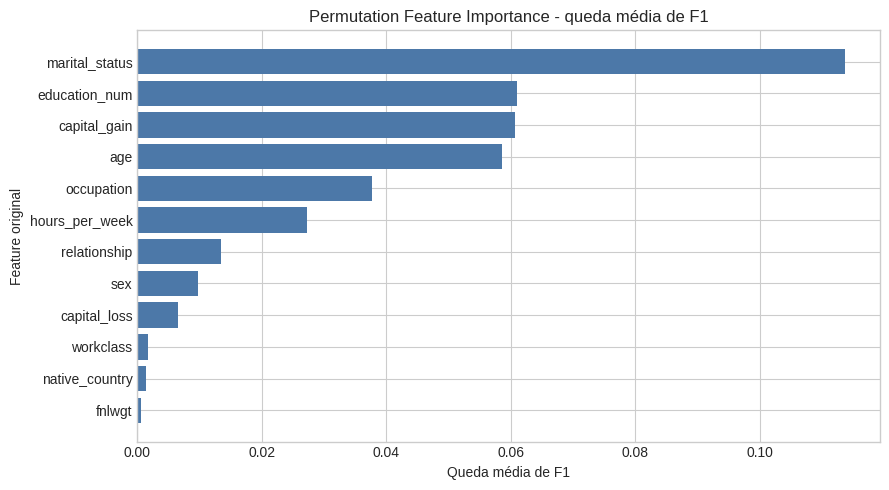

In [16]:
top_importance = importance_df.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_importance['feature_group'], top_importance['mean_drop_f1'], color='#4C78A8')
ax.set_title('Permutation Feature Importance - queda média de F1')
ax.set_xlabel('Queda média de F1')
ax.set_ylabel('Feature original')
plt.tight_layout()
plt.show()

## 11. Interpretabilidade individual: gradiente da entrada

Para explicar uma decisão individual, calculamos o gradiente do score da classe prevista em relação às entradas. Em seguida agregamos a magnitude por feature original.

Interpretação: valores maiores indicam entradas às quais a predição local é mais sensível.

In [17]:
def explain_instance_with_gradients(model, X, row_df, index, feature_groups, feature_names, top_k=10):
    x = X[index:index + 1]
    pred = model.predict(x)[0]
    proba = model.predict_proba(x)[0]
    grad = model.input_gradients(x, class_idx=np.array([pred]))[0]
    contribution = np.abs(grad * x[0])

    rows = []
    for group_name, cols in feature_groups.items():
        cols = list(cols)
        rows.append({
            'feature_group': group_name,
            'gradient_x_input_abs': float(contribution[cols].sum()),
        })
    contrib_df = pd.DataFrame(rows).sort_values('gradient_x_input_abs', ascending=False)

    raw_row = row_df.iloc[index]
    print(f'Índice no teste: {index}')
    print(f"Classe real: {raw_row[TARGET_COL]} | Classe prevista: {'>50K' if pred == 1 else '<=50K'}")
    print(f'Probabilidades [<=50K, >50K]: {np.round(proba, 4)}')
    display(raw_row.to_frame('valor'))
    display(contrib_df.head(top_k))
    return contrib_df

positive_hits = np.where((y_test == 1) & (base_pred == 1))[0]
example_index = int(positive_hits[0]) if len(positive_hits) else 0
instance_explanation = explain_instance_with_gradients(
    base_model,
    X_test,
    test_df,
    example_index,
    preprocessor.feature_groups_,
    preprocessor.feature_names_,
    top_k=10,
)

Índice no teste: 2
Classe real: >50K | Classe prevista: >50K
Probabilidades [<=50K, >50K]: [0.4132 0.5868]


,valor
age,28
workclass,Local-gov
fnlwgt,336951
education,Assoc-acdm
education_num,12
marital_status,Married-civ-spouse
occupation,Protective-serv
relationship,Husband
race,White
sex,Male


,feature_group,gradient_x_input_abs
0,age,0.814543
8,occupation,0.589459
7,marital_status,0.509420
6,workclass,0.386671
2,education_num,0.250117
9,relationship,0.111746
12,native_country,0.061611
10,race,0.058666
1,fnlwgt,0.056195
11,sex,0.030265


## 12. Pontos para o relatório

Use os resultados acima para estruturar a discussão final:

- A MLP foi implementada manualmente com forward, backpropagation e mini-batch gradient descent.
- O Adult Income é desbalanceado, então F1/precision/recall são mais informativas que acurácia isolada.
- O modelo tende a refletir diferenças históricas presentes nos dados, especialmente em `sex` e `race`.
- O `reweighing` tenta reduzir a disparidade alterando a contribuição das amostras na loss.
- A permutation importance mostra quais variáveis mais sustentam o desempenho global.
- O gradiente de entrada explica uma decisão individual por sensibilidade local.

Para a entrega, exporte as principais tabelas e gráficos para o relatório de 5/6 páginas.